--- 1. Theoretical Questions: Binary Classification and SoftMax ---
1. Binary Classification Problem (Student Pass/Fail):
   a. Logistic Regression Equation: P(Pass|StudyHours) = 1 / (1 + e^(-(-5 + 0.8 * StudyHours)))
   b. Probability that a student who studies for 7 hours will pass: 0.6457
   c. Predicted class for this student (threshold = 0.5): Pass

2. SoftMax Function for z=[2, 1, 0]:
   Probability for Class 1 (z=2): 0.6652
   Probability for Class 2 (z=1): 0.2447
   Probability for Class 3 (z=0): 0.0900
   Sum of probabilities: 1.0000

--- 2. HR Data Analysis: EDA and Visualizations ---

First 5 rows of the HR dataset:
   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87       

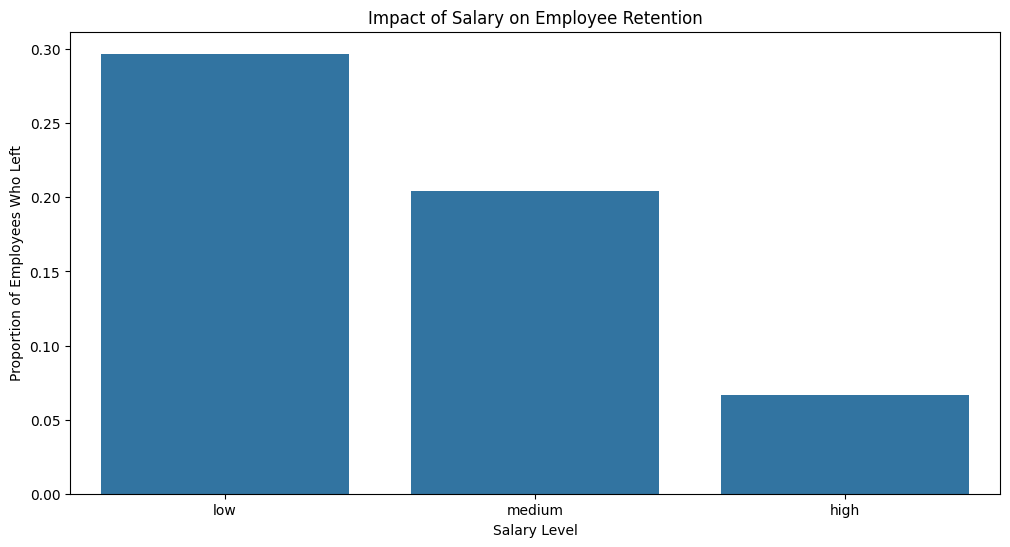

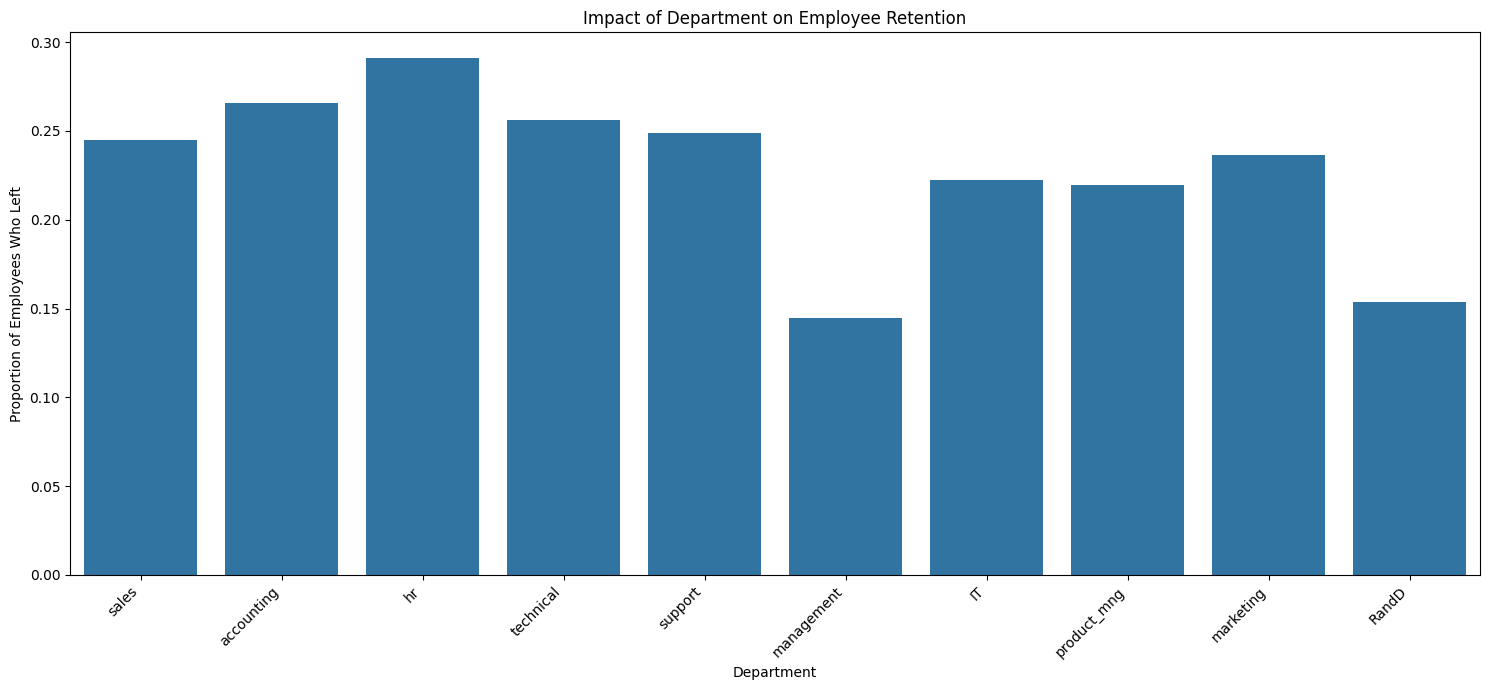


--- 3. HR Data Analysis: Build and Evaluate Logistic Regression Model ---
HR Employee Retention Model Accuracy: 0.7570

--- 4. Zoo Data Analysis: Preprocessing and Model Building ---

First 5 rows of zoo-data.csv with proper header:
  animal_name  hair  feathers  eggs  milk  airborne  aquatic  predator  \
0    aardvark     1         0     0     1         0        0         1   
1    antelope     1         0     0     1         0        0         0   
2        bass     0         0     1     0         0        1         1   
3        bear     1         0     0     1         0        0         1   
4        boar     1         0     0     1         0        0         1   

   toothed  backbone  breathes  venomous  fins  legs  tail  domestic  catsize  \
0        1         1         1         0     0     4     0         0        1   
1        1         1         1         0     0     4     1         0        1   
2        1         1         0         0     1     0     1         0        0 

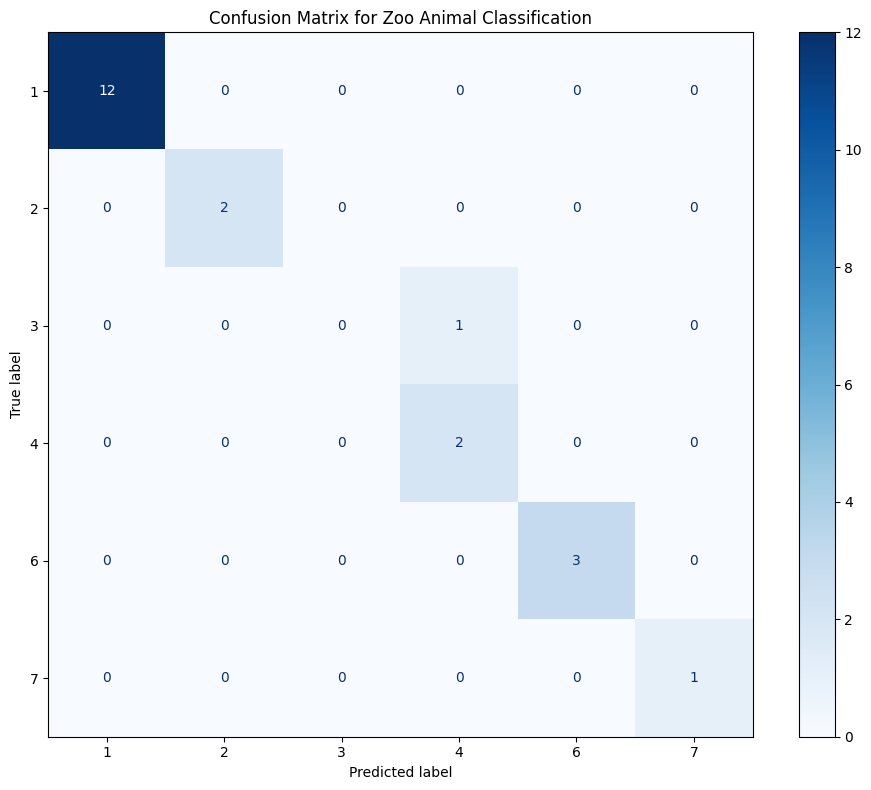

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.multiclass import OneVsRestClassifier

print("--- 1. Theoretical Questions: Binary Classification and SoftMax ---")
a0 = -5
a1 = 0.8
study_hours = 7
threshold = 0.5
print("1. Binary Classification Problem (Student Pass/Fail):")
print(f"   a. Logistic Regression Equation: P(Pass|StudyHours) = 1 / (1 + e^(-(-5 + 0.8 * StudyHours)))")

z_7_hours = a0 + a1 * study_hours

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

probability_pass = sigmoid(z_7_hours)
print(f"   b. Probability that a student who studies for {study_hours} hours will pass: {probability_pass:.4f}")

predicted_class = 'Pass' if probability_pass >= threshold else 'Fail'
print(f"   c. Predicted class for this student (threshold = {threshold}): {predicted_class}")

z_values = np.array([2, 1, 0])

def softmax(z):
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z)

softmax_probabilities = softmax(z_values)

print("\n2. SoftMax Function for z=[2, 1, 0]:")
for i, prob in enumerate(softmax_probabilities):
    print(f"   Probability for Class {i+1} (z={z_values[i]}): {prob:.4f}")
print(f"   Sum of probabilities: {np.sum(softmax_probabilities):.4f}")


print("\n--- 2. HR Data Analysis: EDA and Visualizations ---")

df = pd.read_csv('/content/HR_comma_sep.csv')

print("\nFirst 5 rows of the HR dataset:")
print(df.head())

print("\nConcise summary of the HR DataFrame:")
df.info()

print("\nDescriptive statistics for numerical columns in HR data:")
print(df.describe())

print("\nNumber of unique values in each column of HR data:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

print("\nDistribution of employee retention (0: stayed, 1: left) in HR data:")
print(df['left'].value_counts())

plt.figure(figsize=(12, 6))
sns.barplot(x='salary', y='left', data=df, errorbar=None)
plt.title('Impact of Salary on Employee Retention')
plt.xlabel('Salary Level')
plt.ylabel('Proportion of Employees Who Left')
plt.show()

plt.figure(figsize=(15, 7))
sns.barplot(x='Department', y='left', data=df, errorbar=None)
plt.title('Impact of Department on Employee Retention')
plt.xlabel('Department')
plt.ylabel('Proportion of Employees Who Left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n--- 3. HR Data Analysis: Build and Evaluate Logistic Regression Model ---")
df_model = df.copy()
X_temp = df_model.drop('left', axis=1)
y = df_model['left']

le = LabelEncoder()
X_temp['salary'] = le.fit_transform(X_temp['salary'])

preprocessor_final = ColumnTransformer(
    transformers=[
        ('department_onehot', OneHotEncoder(handle_unknown='ignore'), ['Department'])
    ],
    remainder='passthrough'
)

X_train, X_test, y_train, y_test = train_test_split(X_temp, y, test_size=0.2, random_state=42)

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_final),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42))
])

model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"HR Employee Retention Model Accuracy: {accuracy:.4f}")


print("\n--- 4. Zoo Data Analysis: Preprocessing and Model Building ---")

df_zoo_data = pd.read_csv('/content/zoo-data.csv', header=0)
df_zoo_class = pd.read_csv('/content/zoo-class-type.csv', header=0)

print("\nFirst 5 rows of zoo-data.csv with proper header:")
print(df_zoo_data.head())
print("\nFirst 5 rows of zoo-class-type.csv with proper header:")
print(df_zoo_class.head())

print("\nConcise summary of df_zoo_data:")
df_zoo_data.info()
print("\nDescriptive statistics for numerical columns in df_zoo_data:")
print(df_zoo_data.describe())
print("\nNumber of unique values in each column of df_zoo_data:")
for col in df_zoo_data.columns:
    print(f"{col}: {df_zoo_data[col].nunique()} unique values")

print("\nConcise summary of df_zoo_class:")
df_zoo_class.info()
print("\nDescriptive statistics for numerical columns in df_zoo_class:")
print(df_zoo_class.describe())
print("\nNumber of unique values in each column of df_zoo_class:")
for col in df_zoo_class.columns:
    print(f"{col}: {df_zoo_class[col].nunique()} unique values")

print("\nMerging df_zoo_data with df_zoo_class...")
df_zoo = pd.merge(df_zoo_data, df_zoo_class, left_on='class_type', right_on='Class_Number', how='left')
print("\nFirst 5 rows of the merged DataFrame (df_zoo):")
print(df_zoo.head())
print("\nConcise summary of the merged DataFrame (df_zoo):")
df_zoo.info()
print("\nChecking for missing values in df_zoo:")
print(df_zoo.isnull().sum())
print("\nChecking for duplicate animal names in df_zoo:")
print(df_zoo['animal_name'].duplicated().sum())
print("\nDistribution of animal classes in df_zoo:")
print(df_zoo['Class_Type'].value_counts())

df_zoo_processed = df_zoo.drop(columns=['animal_name', 'Class_Number', 'Number_Of_Animal_Species_In_Class', 'Animal_Names', 'Class_Type'])
X_zoo = df_zoo_processed.drop('class_type', axis=1)
y_zoo = df_zoo_processed['class_type']
X_train_zoo, X_test_zoo, y_train_zoo, y_test_zoo = train_test_split(X_zoo, y_zoo, test_size=0.2, random_state=42)

print("\nShape of X_train_zoo:", X_train_zoo.shape)
print("Shape of y_train_zoo:", y_train_zoo.shape)
print("Shape of X_test_zoo:", X_test_zoo.shape)
print("Shape of y_test_zoo:", y_test_zoo.shape)

model_zoo = OneVsRestClassifier(LogisticRegression(solver='liblinear', random_state=42))
model_zoo.fit(X_train_zoo, y_train_zoo)
y_pred_zoo = model_zoo.predict(X_test_zoo)
accuracy_zoo = accuracy_score(y_test_zoo, y_pred_zoo)
print(f"Zoo Animal Classification Model Accuracy: {accuracy_zoo:.4f}")


print("\n--- 5. Zoo Data Analysis: Evaluate Model and Confusion Matrix ---")
print("\nClassification Report for Zoo Animal Classification:\n")
print(classification_report(y_test_zoo, y_pred_zoo, zero_division=0))

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_estimator(model_zoo, X_test_zoo, y_test_zoo, cmap=plt.cm.Blues, ax=ax)
ax.set_title('Confusion Matrix for Zoo Animal Classification')
plt.tight_layout()
plt.show()